In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("whitegrid")
from scipy import stats
from scipy.stats import chi2_contingency
import category_encoders as ce
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import LabelEncoder

## Data Import

In [12]:
# Import Data
flights = pd.read_csv('flight_dataset.csv')

In [14]:
# Review Data
flights.head()

,Airline,Source,Destination,Total_Stops,Price,Day,Month,Year,Dep_hours,Dep_min,Arrival_hours,Arrival_min,Duration_hours,Duration_min
0,IndiGo,Banglore,New Delhi,0,3897,24,3,2019,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,2,7662,1,5,2019,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,2,13882,9,6,2019,9,25,4,25,19,0
3,IndiGo,Kolkata,Banglore,1,6218,12,5,2019,18,5,23,30,5,25
4,IndiGo,Banglore,New Delhi,1,13302,1,3,2019,16,50,21,35,4,45


## Exploratory Data Analysis (EDA), Data Pre-Processing & Initial Feature Engineering

In [17]:
# Check shape of dataframe - 14 columns, 10683 rows
flights.shape

(10682, 14)

In [19]:
# Check data types - Data types are correct
# Check for missing values - There are no missing values 
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10682 entries, 0 to 10681
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Airline         10682 non-null  object
 1   Source          10682 non-null  object
 2   Destination     10682 non-null  object
 3   Total_Stops     10682 non-null  int64 
 4   Price           10682 non-null  int64 
 5   Day             10682 non-null  int64 
 6   Month           10682 non-null  int64 
 7   Year            10682 non-null  int64 
 8   Dep_hours       10682 non-null  int64 
 9   Dep_min         10682 non-null  int64 
 10  Arrival_hours   10682 non-null  int64 
 11  Arrival_min     10682 non-null  int64 
 12  Duration_hours  10682 non-null  int64 
 13  Duration_min    10682 non-null  int64 
dtypes: int64(11), object(3)
memory usage: 1.1+ MB


In [21]:
# Create 2 columns (Date and Day_Name) to represent day of week
flights['Date (New)'] = pd.to_datetime({
    'year': flights['Year'],
    'month': flights['Month'],
    'day': flights['Day']
})

flights['Day_Name (New)'] = flights['Date (New)'].dt.day_name()

# Show new interpretable features
flights[['Date (New)', 'Day_Name (New)']].head(3)

,Date (New),Day_Name (New)
0,2019-03-24,Sunday
1,2019-05-01,Wednesday
2,2019-06-09,Sunday


In [23]:
# Create 3 columns (Day_Num, Day_sin and Day_cos) to represent day of week
# Convert date to a polar coordinate to input to ML model

# Day_Num ranges from 0-6, where 0 represents Monday and 6 represents Sunday
flights['Day_Num'] = flights['Date (New)'].dt.dayofweek

# Use cyclical encoding as it preserves circular nature of days
# Day of week is represented by polar coordinates (Day_sin, Day_cos)
flights['Day_sin (New)'] = np.sin(2 * np.pi * flights['Day_Num']/7)
flights['Day_cos (New)'] = np.cos(2 * np.pi * flights['Day_Num']/7)

flights = flights.drop('Day_Num', axis=1)

# Show new interpretable features
flights[['Date (New)', 'Day_sin (New)', 'Day_cos (New)']].head(3)

,Date (New),Day_sin (New),Day_cos (New)
0,2019-03-24,-0.781831,0.623490
1,2019-05-01,0.974928,-0.222521
2,2019-06-09,-0.781831,0.623490


In [25]:
# Create 2 columns (dep_time_of_day and arr_time_of_day) that represents departure and arrival time of day
def time_of_day(hour):
    """
    Converts hour of day to time of day (Morning, Afternoon, Evening, Night)
    """
    
    if 5 <= hour <= 11:
        return 'Morning'
    elif 12 <= hour <= 15:
        return 'Afternoon'
    elif 16 <= hour <= 18:
        return 'Evening'
    else:
        return 'Night'

flights['dep_time_of_day (New)'] = flights['Dep_hours'].apply(time_of_day)
flights['arr_time_of_day (New)'] = flights['Arrival_hours'].apply(time_of_day)

# Show new interpretable features
flights[['Dep_hours', 'dep_time_of_day (New)', 'Arrival_hours', 'arr_time_of_day (New)']].head(3)

,Dep_hours,dep_time_of_day (New),Arrival_hours,arr_time_of_day (New)
0,22,Night,1,Night
1,5,Morning,13,Afternoon
2,9,Morning,4,Night


In [27]:
# Create 1 new binary column (is_holiday) to highlight if flight was on a public holiday in India
def is_holiday(date):
    """
    Checks if date was a public holiday in India in 2019
    Returns 1 if true, 0 if false
    """
    
    # List of public holidays in India in 2019
    dates = [
    '26.01.2019', '04.03.2019', '21.03.2019', '17.04.2019', '18.05.2019',
    '05.06.2019', '12.08.2019', '15.08.2019', '19.08.2019', '24.08.2019',
    '10.09.2019', '02.10.2019', '08.10.2019', '27.10.2019', '10.11.2019',
    '12.11.2019', '25.12.2019'
    ]
    
    dates = pd.to_datetime(dates, format='%d.%m.%Y')

    # Time frames containing public holidays in India
    # Window of +- 1 day around each public holiday
    time_frames = [(date - pd.Timedelta(days=1), date + pd.Timedelta(days=1)) for date in dates]

    for start, end in time_frames:
        if start <= date <= end:
            return 1

    return 0

# Binary column is_holiday equals 1 if flight was on a public holiday in India
flights['is_holiday (New)'] = flights['Date (New)'].apply(is_holiday)

# Show new interpretable feature
flights[['Date (New)', 'is_holiday (New)']].head(3)

,Date (New),is_holiday (New)
0,2019-03-24,0
1,2019-05-01,0
2,2019-06-09,0


In [28]:
# Create 1 new column (duration_category) to show flight duration in bins
bins = [0, 3, 6, 9, 12, float('inf')]
duration_bins = ['1-3 Hours', '4-6 Hours', '7-9 Hours', '10-12 Hours', '12+ Hours']

flights['duration_category (New)'] = pd.cut(flights['Duration_hours'], bins=bins, labels=duration_bins)

# Show new feature
flights[['Duration_hours', 'duration_category (New)']].head(3)

,Duration_hours,duration_category (New)
0,2,1-3 Hours
1,7,7-9 Hours
2,19,12+ Hours


In [29]:
# Create 1 new column (duration_total_hours) by combining Duration_Hours and Duration_min
flights['duration_total_hours (New)'] = (flights['Duration_hours'] + flights['Duration_min']/60).round(2)
flights[['Duration_hours', 'Duration_min', 'duration_total_hours (New)']].head(3)

,Duration_hours,Duration_min,duration_total_hours (New)
0,2,50,2.83
1,7,25,7.42
2,19,0,19.00


In [33]:
# Dropping columns that were used to create more interpretable columns
flights.drop(['Day', 'Year', 'Dep_hours', 'Dep_min', 'Arrival_hours', 'Arrival_min', 'Duration_hours', 'Duration_min', 'Date (New)'], axis=1, inplace=True)

# Renaming columns 
flights.rename(columns={'Day_Name (New)': 'Day_Name', 'arr_time_of_day (New)': 'arr_time_of_day', 'dep_time_of_day (New)': 'dep_time_of_day', 'is_holiday (New)': 'is_holiday', 'duration_category (New)': 'duration_category', 'duration_total_hours (New)': 'duration_total_hours', 'Day_sin (New)': 'Day_sin', 'Day_cos (New)': 'Day_cos'}, inplace=True)

# Review Data with new columns
flights.head(3)

,Airline,Source,Destination,Total_Stops,Price,Month,Day_Name,Day_sin,Day_cos,dep_time_of_day,arr_time_of_day,is_holiday,duration_category,duration_total_hours
0,IndiGo,Banglore,New Delhi,0,3897,3,Sunday,-0.781831,0.623490,Night,Night,0,1-3 Hours,2.83
1,Air India,Kolkata,Banglore,2,7662,5,Wednesday,0.974928,-0.222521,Morning,Afternoon,0,7-9 Hours,7.42
2,Jet Airways,Delhi,Cochin,2,13882,6,Sunday,-0.781831,0.623490,Morning,Night,0,12+ Hours,19.00


In [35]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10682 entries, 0 to 10681
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Airline               10682 non-null  object  
 1   Source                10682 non-null  object  
 2   Destination           10682 non-null  object  
 3   Total_Stops           10682 non-null  int64   
 4   Price                 10682 non-null  int64   
 5   Month                 10682 non-null  int64   
 6   Day_Name              10682 non-null  object  
 7   Day_sin               10682 non-null  float64 
 8   Day_cos               10682 non-null  float64 
 9   dep_time_of_day       10682 non-null  object  
 10  arr_time_of_day       10682 non-null  object  
 11  is_holiday            10682 non-null  int64   
 12  duration_category     10682 non-null  category
 13  duration_total_hours  10682 non-null  float64 
dtypes: category(1), float64(3), int64(4), object(6)
memory

## Initial Data Visualisations

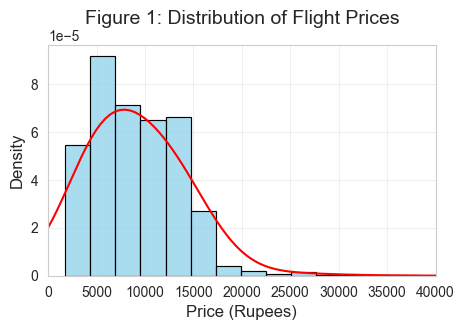

In [38]:
# Figure 1 (Distribution of Flight Prices)
# Checking Ticket Price Distribution - Shows a right-skew
# Transform flight prices to get more normally distributed data
plt.figure(figsize=(5,3))
sns.histplot(flights['Price'], bins=30, color='skyblue', edgecolor='black', alpha=0.7, stat='density')
sns.kdeplot(data=flights['Price'], bw_adjust=5, color='red')


plt.title('Figure 1: Distribution of Flight Prices', fontsize=14, pad=15)
plt.xlabel('Price (Rupees)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xlim(0, 40000)
plt.grid(True, alpha=0.3)

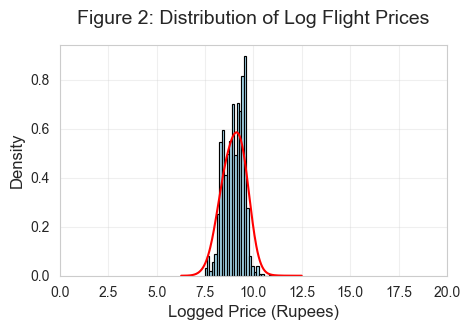

In [40]:
# Log transform prices for target variable to be more normally distributed
flights['log_price'] = np.log1p(flights['Price'])

plt.figure(figsize=(5,3))
sns.histplot(flights['log_price'], bins=30, color='skyblue', edgecolor='black', alpha=0.7, stat='density')
sns.kdeplot(data=flights['log_price'], bw_adjust=5, color='red')


plt.title('Figure 2: Distribution of Log Flight Prices', fontsize=14, pad=15)
plt.xlabel('Logged Price (Rupees)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xlim(0, 20)
plt.grid(True, alpha=0.3)

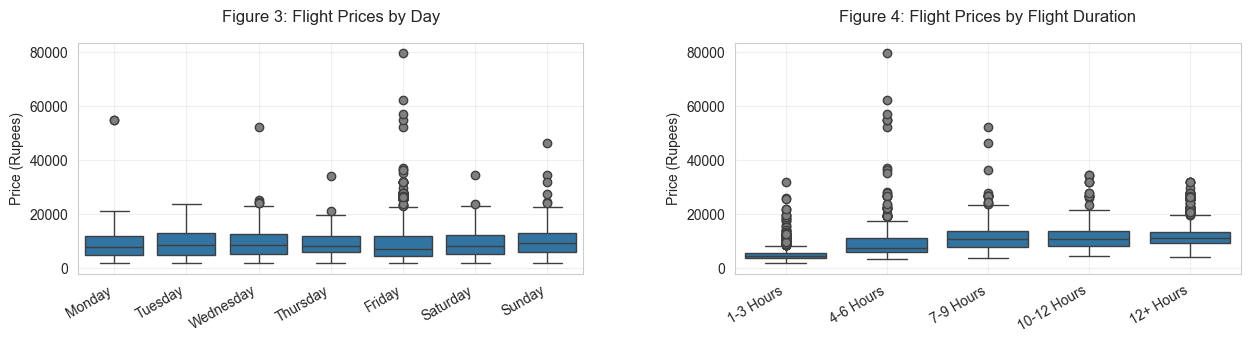

In [42]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 3), gridspec_kw={'wspace':0.3})

# Figure 2 (Distribution of Flight Prices by Month)
# Checking for outliers - Shows presence of outliers
# Note to transform flight prices to get more normally distributed data
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.boxplot(x='Day_Name', y='Price', data=flights, ax=ax1, order=day_order, flierprops={'marker': 'o', 'markerfacecolor': 'gray'})
ax1.set_title('Figure 3: Flight Prices by Day', fontsize=12, pad=15)
ax1.set_ylabel('Price (Rupees)')
ax1.set_xlabel(None)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=30) 
plt.setp(ax1.xaxis.get_majorticklabels(), ha='right')  


# Figure 3 (Distribution of Flight Prices by Flight Duration)
sns.boxplot(x='duration_category', y='Price', data=flights, ax=ax2, order=duration_bins, flierprops={'marker': 'o', 'markerfacecolor': 'gray'})
ax2.set_title('Figure 4: Flight Prices by Flight Duration', fontsize=12, pad=15)
ax2.set_ylabel('Price (Rupees)')
ax2.set_xlabel(None)
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=30) 
plt.setp(ax2.xaxis.get_majorticklabels(), ha='right') 

plt.show()

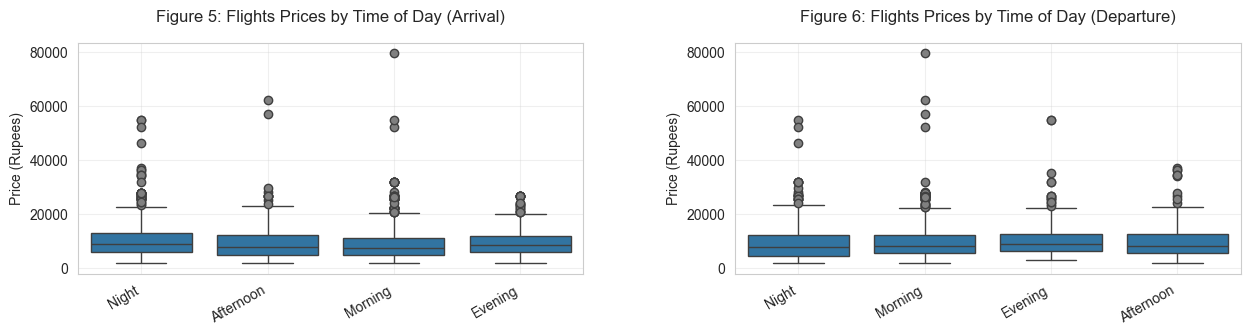

In [44]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 3), gridspec_kw={'wspace':0.3})

# Figure 3 (Distribution of Flight Prices by Departure Time of Day)
# Checking for outliers - Shows presence of outliers
sns.boxplot(x='arr_time_of_day', y='Price', data=flights, ax=ax1, flierprops={'marker': 'o', 'markerfacecolor': 'gray'})
ax1.set_title('Figure 5: Flights Prices by Time of Day (Arrival)', fontsize=12, pad=15)
ax1.set_ylabel('Price (Rupees)')
ax1.set_xlabel(None)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=30) 
plt.setp(ax1.xaxis.get_majorticklabels(), ha='right') 


# Figure 4 (Distribution of Flight Prices by Arrival Time of Day)
# Checking for outliers - Shows presence of outliers
sns.boxplot(x='dep_time_of_day', y='Price', data=flights, ax=ax2, flierprops={'marker': 'o', 'markerfacecolor': 'gray'})
ax2.set_title('Figure 6: Flights Prices by Time of Day (Departure)', fontsize=12, pad=15)
ax2.set_ylabel('Price (Rupees)')
ax2.set_xlabel(None)
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=30) 
plt.setp(ax2.xaxis.get_majorticklabels(), ha='right') 

plt.show()

## Feature Summary Statistics

In [47]:
# Summary Statistics (Day of the Week)
flights['Day_Name'] = pd.Categorical(flights['Day_Name'], categories=day_order, ordered=True)

day_summary = flights.groupby('Day_Name', observed=False)['Price'].agg(['mean', 'median', 'std', 'min', 'max']).round(2)
day_summary.columns = ['Avg Price', 'Median Price', 'Price Std', 'Min Price', 'Max Price']
day_summary.rename_axis('Day Name', inplace=True)

day_summary

,Avg Price,Median Price,Price Std,Min Price,Max Price
Day Name,,,,,
Monday,8499.53,7740.0,4162.91,1965,54826
Tuesday,9026.15,8586.0,4137.46,1965,23843
Wednesday,9277.51,8529.0,4489.44,1759,52285
Thursday,8931.38,8367.0,3703.41,1759,34273
Friday,9709.22,7229.0,7881.90,1965,79512
Saturday,8972.91,8372.0,4073.88,1965,34608
Sunday,9525.51,9454.0,4337.56,1965,46490


In [49]:
# Summary Statistics (Departure Time of Day)
time_order = ['Morning', 'Afternoon', 'Evening', 'Night']
flights['dep_time_of_day'] = pd.Categorical(flights['dep_time_of_day'], categories=time_order, ordered=True)

dep_time_summary = flights.groupby('dep_time_of_day', observed=False)['Price'].agg(['mean', 'median', 'std', 'min', 'max']).round(2)
dep_time_summary.columns = ['Avg Price', 'Median Price', 'Price Std', 'Min Price', 'Max Price']
dep_time_summary.rename_axis('Departure Time of Day', inplace=True)

dep_time_summary

,Avg Price,Median Price,Price Std,Min Price,Max Price
Departure Time of Day,,,,,
Morning,9200.55,8372.0,4550.40,1759,79512
Afternoon,9088.12,8018.0,4578.54,1965,36983
Evening,9558.86,8855.0,4396.50,3175,54826
Night,8599.54,7757.0,4815.32,1759,54826


In [51]:
# Summary Statistics (Arrival Time of Day)
flights['arr_time_of_day'] = pd.Categorical(flights['arr_time_of_day'], categories=time_order, ordered=True)

arr_time_summary = flights.groupby('arr_time_of_day', observed=False)['Price'].agg(['mean', 'median', 'std', 'min', 'max']).round(2)
arr_time_summary.columns = ['Avg Price', 'Median Price', 'Price Std', 'Min Price', 'Max Price']
arr_time_summary.rename_axis('Arrival Time of Day', inplace=True)

arr_time_summary

,Avg Price,Median Price,Price Std,Min Price,Max Price
Arrival Time of Day,,,,,
Morning,8357.34,7451.5,4859.98,1759,79512
Afternoon,8680.33,7662.0,4732.36,1965,62427
Evening,9289.59,8576.0,4327.98,2050,26890
Night,9461.34,9001.0,4478.21,1759,54826


In [53]:
# Summary Statistics (Flight Duration)
flights['duration_category'] = pd.Categorical(flights['duration_category'], categories=duration_bins, ordered=True)

duration_summary = flights.groupby('duration_category', observed=False)['Price'].agg(['mean', 'median', 'std', 'min', 'max']).round(2)
duration_summary.columns = ['Avg Price', 'Median Price', 'Price Std', 'Min Price', 'Max Price']
duration_summary.rename_axis('Flight Duration', inplace=True)

duration_summary

,Avg Price,Median Price,Price Std,Min Price,Max Price
Flight Duration,,,,,
1-3 Hours,5032.37,4667.0,2086.07,1759,31945
4-6 Hours,9310.78,7555.0,6028.69,3480,79512
7-9 Hours,11113.15,10699.5,4217.03,3673,52285
10-12 Hours,11230.86,10844.0,3902.60,4487,34608
12+ Hours,11535.30,11150.0,3403.32,4227,31825


In [55]:
# Drop duration_category column as it is directly derived from duration column 
flights = flights.drop('duration_category', axis=1)

# Drop price column as we are using log_prices for model training and evaluation
flights = flights.drop('Price', axis=1)

## Target Correlation Analysis (Features vs Target)

In [58]:
# Split data into train and test sets before doing correlation analysis and target encoding to prevent data leakage during model validation
X = flights.drop('log_price', axis=1)
y = flights['log_price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

# Dataframes for training and testing
train_df = X_train.copy()
train_df['log_price'] = y_train

test_df = X_test.copy()
test_df['log_price'] = y_test

In [60]:
# Keep track of features that do not have significant correlation to target (features with low predictive power)
features_to_drop = []

In [62]:
# Function for correlation analysis on continuous features against target
def correlation_analysis_continuous(df, col_names, corr_threshold=0.3, p_threshold=0.05):
    """
    Perform correlation analysis on continuous continuous features against target to identify features to keep and remove

    Parameters
    ----------
    df: Pandas dataframe 
        Pandas dataframe containing the data
    col_names: list 
        List of continuous columns in dataframe
    corr_threshold: float (optional, default value = 0.3)
        Threshold value we are using for Pearson and Spearman coefficients
    p_threshold: float (optional, default value = 0.05)
        Maximum p-value to consider the correlation statistically significant

    Returns
    -------
    results: dict
        Dictionary with two keys: 'keep' and 'drop', each containing lists of column names to keep and drop 
    """
    results = {'keep': [], 'drop': []}
    print('Correlation Analysis for continuous features: \n')
    
    for col in col_names:
        try:
            
            # Calculating Pearson and Spearman coefficients, with their respective p-values
            pearson_coef, pearson_p = stats.pearsonr(df[col], df['log_price'])
            spearman_coef, spearman_p = stats.spearmanr(df[col], df['log_price'])

            print(f'Feature: {col}')
            print(f'Pearson Correlation: {pearson_coef:.3f} (p-value: {pearson_p:.3f})')
            print(f'Spearman Correlation: {spearman_coef:.3f} (p-value: {spearman_p:.3f})')
            
            # Checking if Pearson and Spearman coefficient are significant (also checks associated p-values)
            pearson_significant = (abs(pearson_coef) >= corr_threshold) and (pearson_p < p_threshold)
            spearman_significant = (abs(spearman_coef) >= corr_threshold) and (spearman_p < p_threshold)
            
            if pearson_significant or spearman_significant:
                print('Keep feature (significant correlation found!)')
                results['keep'].append(col)
            else:
                print('Drop feature (no significant correlation found!)')
                results['drop'].append(col)
            
            print('\n')
            
        except Exception as e:
            print(f"Error analyzing {col}: {str(e)}")

    return results

In [64]:
# Correlation analysis for continuous features
continuous_features = ['duration_total_hours', 'Day_sin', 'Day_cos']
features_to_drop_continuous = correlation_analysis_continuous(train_df, continuous_features)['drop']

features_to_drop.extend(features_to_drop_continuous)
print(f'Continuous features to drop: {features_to_drop_continuous}')

Correlation Analysis for continuous features: 

Feature: duration_total_hours
Pearson Correlation: 0.594 (p-value: 0.000)
Spearman Correlation: 0.695 (p-value: 0.000)
Keep feature (significant correlation found!)


Feature: Day_sin
Pearson Correlation: -0.004 (p-value: 0.704)
Spearman Correlation: 0.008 (p-value: 0.467)
Drop feature (no significant correlation found!)


Feature: Day_cos
Pearson Correlation: -0.010 (p-value: 0.341)
Spearman Correlation: 0.004 (p-value: 0.730)
Drop feature (no significant correlation found!)


Continuous features to drop: ['Day_sin', 'Day_cos']


In [66]:
# Function for correlation analysis on high cardinality categorical features against target
# Uses Mutual Information (MI), which measures how much knowing a feature reduces uncertainty of the target variable
def correlation_analysis_categorical_highcar(df, col_names, threshold=0.8, random_state=42):
    """
    Perform correlation analysis on high-cardinality categorical features against target to identify features to keep and remove

    Parameters
    ----------
    df: Pandas dataframe 
        Pandas dataframe containing the data
    col_names: list 
        List of high cardinality discrete columns in dataframe
    threshold: float (optional, default value = 0.8)
        Threshold value we are using for Mutual Information (MI) scores
    random_state: integer (optional, default value = 42)
        Seed to controls the randomness in the mutual information estimation algorithm

    Returns
    -------
    results: dict
        Dictionary with two keys: 'keep' and 'drop', each containing lists of column names to keep and drop 
    """
    results = {'keep': [], 'drop': []}
    print('Correlation Analysis for high-cardinality categorical features: \n')

    try:
        for col in col_names:
            # Convert categorical string values into numeric codes
            le = LabelEncoder() 
            feature_encoded = le.fit_transform(train_df[col].astype(str))
    
            # Calculate mutual information 
            mi_score = mutual_info_regression(
                feature_encoded.reshape(-1, 1),
                df['log_price'],
                random_state=42,
                n_neighbors=3
            )[0].round(3)
    
            print(f'Feature: {col}')
            print(f'Mutual Information score: {mi_score}')
    
            if mi_score > threshold:
                print('Keep feature (strong relationship found between feature and target!)')
                results['keep'].append(col)
            else:
                print('Drop feature (weak relationship found between feature and target!)')
                results['drop'].append(col)
    
            print('\n')
            
    except Exception as e:
            print(f"Error analyzing {col}: {str(e)}")
    
    return results

In [68]:
# Correlation analysis for high-cardinality discrete features
categorical_features_highcar = ['Airline', 'Source', 'Destination']
features_to_drop_categorical_highcar = correlation_analysis_categorical_highcar(train_df, categorical_features_highcar)['drop']

features_to_drop.extend(features_to_drop_categorical_highcar)
print(f'High cardinality features to drop: {features_to_drop_categorical_highcar}')

Correlation Analysis for high-cardinality categorical features: 

Feature: Airline
Mutual Information score: 1.287
Keep feature (strong relationship found between feature and target!)


Feature: Source
Mutual Information score: 1.039
Keep feature (strong relationship found between feature and target!)


Feature: Destination
Mutual Information score: 1.145
Keep feature (strong relationship found between feature and target!)


High cardinality features to drop: []


In [70]:
# Function for correlation analysis on binary features against target
def correlation_analysis_binary(df, col_names, corr_threshold=0.2, p_threshold=0.05):
    """
    Perform correlation analysis on continuous features against target to identify features to keep and remove

    Parameters
    ----------
    df: Pandas dataframe 
        Pandas dataframe containing the data
    col_names: list 
        List of binary columns in dataframe
    corr_threshold: float (optional, default value = 0.3)
        Threshold value we are using for Pearson and Spearman coefficients
    p_threshold: float (optional, default value = 0.05)
        Maximum p-value to consider the correlation statistically significant

    Returns
    -------
    results: dict
        Dictionary with two keys: 'keep' and 'drop', each containing lists of column names to keep and drop 
    """
    results = {'keep': [], 'drop': []}
    print('Correlation Analysis for binary features: \n')
    
    for col in col_names:
        try:
            
            # Calculating Point Biserial coefficient, with its respective p-value
            pb_coef, pb_p = stats.pointbiserialr(df['log_price'], df[col])

            print(f'Feature: {col}')
            print(f'Pearson Correlation: {pb_coef:.3f} (p-value: {pb_p:.3f})')
            
            # Checking if PB coefficient is significant (also checks associated p-value)
            pb_significant = (abs(pb_coef) >= corr_threshold) and (pb_p < p_threshold)
            
            if pb_significant:
                print('Keep feature (significant correlation found!)')
                results['keep'].append(col)
            else:
                print('Drop feature (no significant correlation found!)')
                results['drop'].append(col)
            
            print('\n')
            
        except Exception as e:
            print(f"Error analyzing {col}: {str(e)}")

    return results

In [72]:
# Correlation analysis for binary features
binary_features = ['is_holiday']
features_to_drop_binary = correlation_analysis_binary(train_df, binary_features)['drop']

features_to_drop.extend(features_to_drop_binary)
print(f'Binary features to drop: {features_to_drop_binary}')

Correlation Analysis for binary features: 

Feature: is_holiday
Pearson Correlation: 0.066 (p-value: 0.000)
Drop feature (no significant correlation found!)


Binary features to drop: ['is_holiday']


In [74]:
# Function for correlation analysis on low cardinality categorical features against target
def correlation_analysis_categorical_lowcar(df, col_names, corr_threshold=2, p_threshold=0.05):
    """
    Perform correlation analysis on low-cardinality categorical features against target to identify features to keep and remove

    Parameters
    ----------
    df: Pandas dataframe 
        Pandas dataframe containing the data
    col_names: list 
        List of low cardinality discrete columns in dataframe
    corr_threshold: float (optional, default value = 0.3)
        Threshold value we are using for Pearson and Spearman coefficients
    p_threshold: float (optional, default value = 0.05)
        Maximum p-value to consider the correlation statistically significant

    Returns
    -------
    results: dict
        Dictionary with two keys: 'keep' and 'drop', each containing lists of column names to keep and drop 
    """
    results = {'keep': [], 'drop': []}
    print('Correlation Analysis for low-cardinality categorical features: \n')
    
    for col in col_names:
        try:
            # Performing ANOVA tests on low-cardinality categorical features
            # Calculating F-Statistic value, along with its associated p-value
            categories = df[col].unique()
            anova_groups = [df[df[col] == cat]['log_price'] for cat in categories]
            f_stat, p_value = stats.f_oneway(*anova_groups)
    
            print(f'Feature: {col}')
            print(f'F-Statistic: {f_stat:.3f} (p-value: {p_value:.3f})')
            
            anova_significant = (abs(f_stat) >= corr_threshold) and (p_value < p_threshold)
            if anova_significant:
                print('Keep feature (significant correlation found!)')
                results['keep'].append(col)
            else:
                print('Drop feature (no significant correlation found!)')
                results['drop'].append(col)
                
            print('\n')
           
        except Exception as e:
            print(f"Error analyzing {col}: {str(e)}")

    return results

In [76]:
# Correlation analysis for low-cardinality discrete features
categorical_features_lowcar = ['Total_Stops', 'Month', 'dep_time_of_day', 'arr_time_of_day', 'Day_Name']
features_to_drop_categorical_lowcar = correlation_analysis_categorical_lowcar(train_df, categorical_features_lowcar)['drop']


features_to_drop.extend(features_to_drop_categorical_lowcar)
print(f'Low cardinality features to drop: {features_to_drop_categorical_lowcar}')

Correlation Analysis for low-cardinality categorical features: 

Feature: Total_Stops
F-Statistic: 3468.005 (p-value: 0.000)
Keep feature (significant correlation found!)


Feature: Month
F-Statistic: 245.011 (p-value: 0.000)
Keep feature (significant correlation found!)


Feature: dep_time_of_day
F-Statistic: 36.372 (p-value: 0.000)
Keep feature (significant correlation found!)


Feature: arr_time_of_day
F-Statistic: 44.163 (p-value: 0.000)
Keep feature (significant correlation found!)


Feature: Day_Name
F-Statistic: 7.759 (p-value: 0.000)
Keep feature (significant correlation found!)


Low cardinality features to drop: []


In [78]:
# Features to drop based on correlation analysis
print(f'Features to drop: {features_to_drop}')

# Drop features with low predictive power 
train_df = train_df.drop(columns=features_to_drop)
test_df = test_df.drop(columns=features_to_drop)

Features to drop: ['Day_sin', 'Day_cos', 'is_holiday']


In [80]:
train_df.head(3)

,Airline,Source,Destination,Total_Stops,Month,Day_Name,dep_time_of_day,arr_time_of_day,duration_total_hours,log_price
2002,Vistara,Banglore,New Delhi,0,3,Sunday,Night,Night,2.92,8.378850
6307,GoAir,Kolkata,Banglore,1,4,Monday,Evening,Night,7.58,8.551015
7438,IndiGo,Chennai,Kolkata,0,5,Monday,Afternoon,Afternoon,2.33,8.188133


## Feature Encodings

In [83]:
# Encoding categorical features 
# Use one-hot encoding for low-cardinality categorical features
def one_hot_encode(df):
    categorical_features_lowcar = ['dep_time_of_day', 'arr_time_of_day', 'Day_Name']
    
    dummies = pd.get_dummies(df[categorical_features_lowcar], 
                             drop_first=False, 
                             dtype=int)
    
    total_stops_dummies = pd.get_dummies(df['Total_Stops'], 
                                         prefix='Total_Stops', 
                                         dtype=int)
    
    month_dummies = pd.get_dummies(df['Month'], 
                                    prefix='Month', 
                                    dtype=int)
    
    df = pd.concat([df, dummies, total_stops_dummies, month_dummies], axis=1)
    
    # Drop low-cardinality categorical features after performing one-hot encoding 
    categorical_features_lowcar.append('Month')
    categorical_features_lowcar.append('Total_Stops')
    df = df.drop(columns=categorical_features_lowcar)

    return df

train_df = one_hot_encode(train_df)
test_df = one_hot_encode(test_df)

In [85]:
# Use target encoding for high-cardinality categorical features
categorical_features_highcar = ['Airline', 'Source', 'Destination']

# Create dictionaries to store the encoding mappings
encoding_mappings = {}

# Create encoded features for high-cardinality categorical features
for feature in categorical_features_highcar:
    encoding_map = train_df.groupby(feature)['log_price'].mean() # Returns series object(category: category mean price)
    encoding_mappings[feature] = encoding_map

    # Create new column with target-encoded value
    new_col_name = f"{feature}_target_encoded"
    train_df[new_col_name] = train_df[feature].map(encoding_map)


# Apply same encodings to test set
for feature in categorical_features_highcar:
    new_col_name = f"{feature}_target_encoded"
    test_df[new_col_name] = test_df[feature].map(encoding_mappings[feature])

# Drop high-cardinality categorical features after performing target encoding 
train_df = train_df.drop(categorical_features_highcar, axis=1)
test_df = test_df.drop(categorical_features_highcar, axis=1)

## Multicollinearity Analysis (Features vs Features)

In [88]:
corr_matrix = train_df.corr()
corr_matrix

,duration_total_hours,log_price,dep_time_of_day_Morning,dep_time_of_day_Afternoon,dep_time_of_day_Evening,dep_time_of_day_Night,arr_time_of_day_Morning,arr_time_of_day_Afternoon,arr_time_of_day_Evening,arr_time_of_day_Night,...,Total_Stops_1,Total_Stops_2,Total_Stops_3,Month_3,Month_4,Month_5,Month_6,Airline_target_encoded,Source_target_encoded,Destination_target_encoded
duration_total_hours,1.000000,0.594109,0.022603,-0.035961,0.061066,-0.047815,-0.012733,-0.040563,-0.013767,0.048292,...,0.279025,0.478995,0.118120,0.042820,-0.175632,0.057759,0.015452,0.480030,0.427355,0.472529
log_price,0.594109,1.000000,0.053897,-0.013890,0.061362,-0.101388,-0.098854,-0.049617,0.021758,0.103957,...,0.431200,0.345517,0.057410,0.161970,-0.256403,0.024424,-0.009575,0.675382,0.507786,0.599059
dep_time_of_day_Morning,0.022603,0.053897,1.000000,-0.366845,-0.388934,-0.536226,0.185343,0.158049,-0.021259,-0.254098,...,0.023076,0.052459,0.045173,0.047062,-0.032443,-0.025427,0.002771,0.020922,0.034837,0.055118
dep_time_of_day_Afternoon,-0.035961,-0.013890,-0.366845,1.000000,-0.167863,-0.231434,-0.117538,0.021929,0.212786,-0.047985,...,-0.023694,0.024687,0.000417,-0.028129,-0.005306,-0.006997,0.036539,0.009338,0.023381,0.022489
dep_time_of_day_Evening,0.061066,0.061362,-0.388934,-0.167863,1.000000,-0.245370,-0.073520,-0.105858,-0.026778,0.153480,...,0.070439,-0.043043,-0.017350,-0.033642,0.018366,0.034263,-0.015022,0.012974,0.032233,0.014244
dep_time_of_day_Night,-0.047815,-0.101388,-0.536226,-0.231434,-0.245370,1.000000,-0.059043,-0.111334,-0.121746,0.202824,...,-0.065777,-0.044199,-0.037832,-0.004010,0.026262,0.006453,-0.019680,-0.042063,-0.084989,-0.092716
arr_time_of_day_Morning,-0.012733,-0.098854,0.185343,-0.117538,-0.073520,-0.059043,1.000000,-0.223549,-0.172952,-0.550914,...,-0.110197,-0.031485,0.001732,0.029289,0.032402,0.023166,-0.071307,-0.085514,-0.195108,-0.152347
arr_time_of_day_Afternoon,-0.040563,-0.049617,0.158049,0.021929,-0.105858,-0.111334,-0.223549,1.000000,-0.144270,-0.459551,...,-0.055173,0.019410,-0.018160,-0.007162,0.018884,-0.026608,0.021190,-0.052043,-0.041272,-0.035572
arr_time_of_day_Evening,-0.013767,0.021758,-0.021259,0.212786,-0.026778,-0.121746,-0.172952,-0.144270,1.000000,-0.355539,...,0.032876,-0.062947,-0.015719,0.078993,0.017525,-0.014399,-0.070118,0.035920,0.002184,0.014424
arr_time_of_day_Night,0.048292,0.103957,-0.254098,-0.047985,0.153480,0.202824,-0.550914,-0.459551,-0.355539,1.000000,...,0.110593,0.049512,0.021294,-0.066312,-0.050836,0.009125,0.085112,0.086284,0.188406,0.141894


In [90]:
# Function to do pairwise correlation analysis between features to mitigate multicollinearity
def find_high_correlations(corr_matrix, threshold=0.8):
    # Get upper triangle to avoid duplicates
    upper_tri = corr_matrix.where(
        np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    )
    
    high_corr_pairs = []
    for col in upper_tri.columns:
        for row in upper_tri.index:
            corr_val = upper_tri.loc[row, col]
            if abs(corr_val) > threshold:
                high_corr_pairs.append((row, col, corr_val))
    
    return sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True)

# Find problematic pairs
high_corr = find_high_correlations(corr_matrix, 0.8)
if high_corr:
    for feat1, feat2, corr_val in high_corr:
        print(f"{feat1} <-> {feat2}: {corr_val:.3f}")
else:
    print('No significant correlation found between features!')
    print('No additional features to be removed!')


Source_target_encoded <-> Destination_target_encoded: 0.848


In [92]:
# Function for plotting heatmaps for continuous features which have high correlation to target
def plot_heatmap_significant(df, features_to_keep, plot_width):
    """
    Plots 2 heatmaps for statistically significant continuous features to target (Pearson and Spearman coefficient)

    Parameters
    ----------
    df: Pandas dataframe 
        Pandas dataframe containing the data
    features_to_keep: list
        List of continuous features that have significant correlation to target
        
    Returns
    -------
    NONE
    """
    features = features_to_keep.copy()

    # Get correlation matrix for both coefficients
    pearson_matrix = df[features].corr(method='pearson')
    spearman_matrix = df[features].corr(method='spearman')

    # Plots both correlation heatmaps on the same plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(plot_width, 6))

    # Plot Pearson heatmap
    im1 = sns.heatmap(pearson_matrix, annot=True, cmap='coolwarm', 
                     vmin=-1, vmax=1, center=0, ax=ax1, cbar=False, fmt='.2f')
    ax1.set_title('Pearson Correlation Matrix')
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
    
    # Plot Spearman heatmap
    im2 = sns.heatmap(spearman_matrix, annot=True, cmap='coolwarm', 
                     vmin=-1, vmax=1, center=0, ax=ax2, cbar_ax=plt.axes([0.92, 0.15, 0.02, 0.7]), fmt='.2f')
    ax2.set_title('Spearman Correlation Matrix')
    ax2.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
    
    plt.suptitle('Correlation Analysis', fontsize=16, y=0.98)
    plt.show()

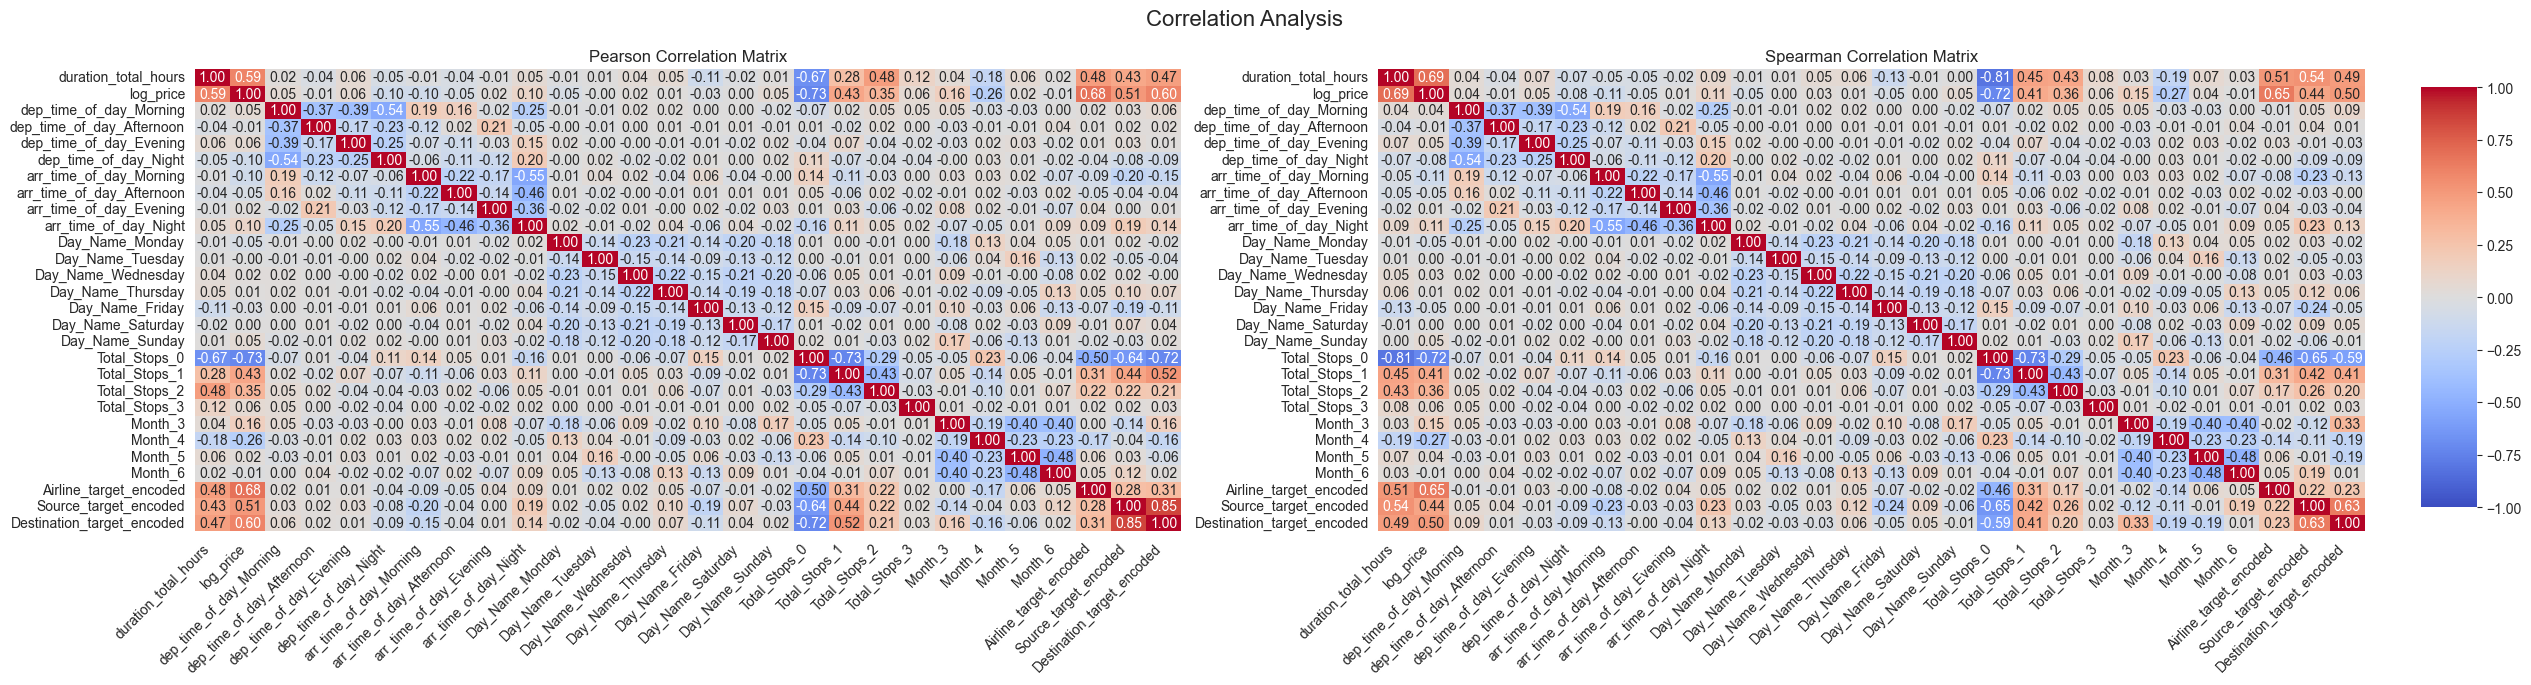

In [94]:
col_names = train_df.columns.tolist()

# Perform pairwise correlation analysis on features to mitigate multicollinearity  
plot_heatmap_significant(train_df, col_names, 28)

## Model Training

In [96]:
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [99]:
# Split test_df and train_df 
X_train = train_df.drop('log_price', axis=1)  
y_train = train_df['log_price']               

X_test = test_df.drop('log_price', axis=1)  
y_test = test_df['log_price']

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

Training set size: (8545, 27)
Test set size: (2137, 27)


In [101]:
# Train and evaluate models using default hyperparameters to see which models perform best on data
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'KNN': KNeighborsRegressor()
}

# Cross-validation scoring
cv_results = {}
cv_scores = {}

for name, model in models.items():
    scores = cross_val_score(
        model, X_train, y_train, 
        cv=5, 
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )
    
    # Convert MSE to positive RMSE
    rmse_scores = np.sqrt(-scores)
    cv_results[name] = rmse_scores
    cv_scores[name] = rmse_scores.mean()
    
    print(f"{name:15} | RMSE: {rmse_scores.mean():.4f} (±{rmse_scores.std():.4f})")

Linear Regression | RMSE: 0.2723 (±0.0073)
Ridge           | RMSE: 0.2723 (±0.0073)
Random Forest   | RMSE: 0.2322 (±0.0096)
Gradient Boosting | RMSE: 0.2304 (±0.0076)
KNN             | RMSE: 0.2793 (±0.0107)


In [102]:
# Sort models by RMSE scores
sorted_models = sorted(cv_scores.items(), key=lambda x: x[1])

# Tune hyperparameters for top performing models
top_models = [name for name, score in sorted_models[:3]]
print(f"Tuning hyperparameters for top 3 models: {top_models}")

Tuning hyperparameters for top 3 models: ['Gradient Boosting', 'Random Forest', 'Ridge']


In [105]:
# Hyperparameter grids for each model
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5]
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200],
        'max_depth': [3, 5],
        'learning_rate': [0.1, 0.2]
    },
    'Ridge': {
        'alpha': [0.1, 1.0, 10.0, 100.0]
    },
    'KNN': {
        'n_neighbors': [3, 5, 7],
        'weights': ['uniform', 'distance']
    }
}


# Run gridsearch on top performing models to find best combination of hyperparameters
tuned_models = {}

for model_name in top_models:
    if model_name in param_grids:
        print(f"Tuning {model_name}...")
        
        model = models[model_name]
        param_grid = param_grids[model_name]
        
        # Grid search with cross-validation
        grid_search = GridSearchCV(
            model, param_grid, 
            cv=5, 
            scoring='neg_mean_squared_error',
            n_jobs=-1,
            verbose=0
        )
        
        grid_search.fit(X_train, y_train)
        
        # Store trained model object with best hyperparameters
        best_rmse = np.sqrt(-grid_search.best_score_)
        tuned_models[model_name] = [grid_search.best_estimator_, best_rmse]
        
        print(f"{model_name:15} | Best RMSE: {best_rmse:.4f}")
        print(f"Best params: {grid_search.best_params_}")
        print()

Tuning Gradient Boosting...
Gradient Boosting | Best RMSE: 0.2129
Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}

Tuning Random Forest...
Random Forest   | Best RMSE: 0.2176
Best params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}

Tuning Ridge...
Ridge           | Best RMSE: 0.2724
Best params: {'alpha': 1.0}



In [107]:
# Sort models by RMSE scores post gridsearch
sorted_models_post_gridsearch = sorted(tuned_models.items(), key=lambda x: x[1][1])

print(f"=== FINAL MODEL SELECTION ===")
print(f"Best Model: {sorted_models_post_gridsearch[0][0]}")
print(f"CV RMSE: {sorted_models_post_gridsearch[0][1][1]:.4f}")

best_model = sorted_models_post_gridsearch[0][1][0]

=== FINAL MODEL SELECTION ===
Best Model: Gradient Boosting
CV RMSE: 0.2129


## Model Evaluation

In [110]:
y_pred = best_model.predict(X_test)

# Final test metrics
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_mae = mean_absolute_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

In [112]:
print(f"=== FINAL TEST SET PERFORMANCE ===")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAE:  {test_mae:.4f}")
print(f"R²:   {test_r2:.4f}")

=== FINAL TEST SET PERFORMANCE ===
RMSE: 0.2090
MAE:  0.1513
R²:   0.8338
